In [1]:
# !pip install xgboost
import pandas as pd
from collections import defaultdict
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.ticker import FuncFormatter
from matplotlib import font_manager
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import LogFormatterSciNotation
import seaborn as sns
import joblib
import os
import xgboost as xgb

import psi4
from helper_CC_ML_spacial import *

font_path = 'Futura Book.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path, size='large')
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams.update({'font.size': 12})

  Threads set to 12 by Python driver.


In [2]:
def formatter(x, pos):
    if x != 0:
        return f'{int(x/1000)}k'
    else:
        return 0

In [3]:
# Most important features (top 5 by SHAP):
# doublecheck: Numerator of the MP2 t2-amplitude, two-electron integral <ik || ab>
# t2start: Initial MP2 t2-amplitude
# t2mag: Magnitude of the MP2 t2-amplitude
# orbdiff: Denominator of the MP2 t2-amplitude
# diag: Binary feature denoting whether a=b (virtual orbits are the same)
top5 = ['doublecheck', 't2start', 't2mag', 'orbdiff', 'diag']

# 31 Features order in X, including t2
properties=['Evir1', 'Hvir1', 'Jvir1', 'Kvir1', 'Evir2', 'Hvir2', 'Jvir2', 'Kvir2', 'Eocc1', 'Jocc1', 'Kocc1', 'Hocc1','Eocc2', 'Jocc2', 'Kocc2', 'Hocc2', 'Jia1', 'Jia2', 'Kia1', 'Kia2','diag', 'orbdiff', 'doublecheck', 't2start', 't2mag', 't2sign', 'Jia1mag', 'Jia2mag','Kia1mag', 'Kia2mag','t2']

# For some reason loading in the files and predicting the test set results in weird/bad performance. Perhaps this should be looked into... For now, I have just retrained the models from scratch, which seemed to have worked.

In [8]:
basis = "STO-3G"
n = 20

fn = f"out/optimised_{basis}_best_model_{n}.pkl"
model = joblib.load(fn)
print("Model loaded.")
print(model.steps, "\n")

Model loaded.
[('scaler', MinMaxScaler(feature_range=(-1, 1))), ('xgb', XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=1, num_parallel_tree=None, ...))] 



In [11]:
# splits_fn = os.path.join(os.path.expanduser("~"), "out", f"faster_{basis}_data_splits_{n}.pkl")
#splits_fn = os.path.join(os.path.expanduser("~"), "out", f"faster_sto_3g_pVDZ_data_splits_20.pkl")
splits_fn = f"/mnt/c/Users/Maxim/Documents/Toronto/Research/code/DDLUCJ/data/{basis}_test_data_splits.pkl"
data = joblib.load(splits_fn)
print("Data splits loaded.")

X_test = data["X_test"]
y_test = data["y_test"]

y_pred = model.predict(X_test)
error = y_pred - y_test
print("Predicted test set.")

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"N: {n}, MAE: {mae}, RMSE: {rmse}, R2: {r2}")

Data splits loaded.
Predicted test set.
N: 20, MAE: 0.00014297754197742653, RMSE: 0.0006323885667942962, R2: 0.9934424496700682


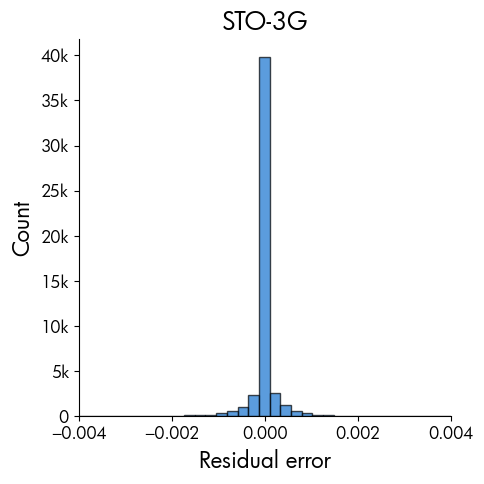

In [13]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(error, bins=200, edgecolor='black', alpha=0.7, color='#1573CF')

ax.set_xlabel('Residual error', fontsize=16)
ax.set_ylabel('Count', fontsize=16)

ax.yaxis.set_major_formatter(FuncFormatter(formatter))
plt.gca().spines['top'].set_color('none')
plt.gca().spines['right'].set_color('none')

plt.xlim(-0.004,0.004)
plt.title(basis, fontsize=18)
plt.tight_layout()
plt.show()

In [14]:
error = y_pred - y_test

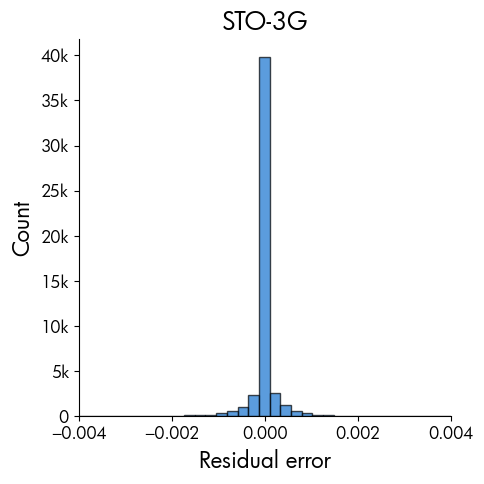

In [15]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(error, bins=200, edgecolor='black', alpha=0.7, color='#1573CF')

ax.set_xlabel('Residual error', fontsize=16)
ax.set_ylabel('Count', fontsize=16)

ax.yaxis.set_major_formatter(FuncFormatter(formatter))
plt.gca().spines['top'].set_color('none')
plt.gca().spines['right'].set_color('none')

plt.xlim(-0.004,0.004)
plt.title(basis, fontsize=18)
plt.tight_layout()
plt.show()

In [16]:
basis = "cc-pVDZ"
n = 20

fn = f"out/optimised_{basis}_best_model_{n}.pkl"
model = joblib.load(fn)
print("Model loaded.")
print(model.steps, "\n")

# splits_fn = os.path.join(os.path.expanduser("~"), "out", f"faster_{basis}_data_splits_{n}.pkl")
#splits_fn = os.path.join(os.path.expanduser("~"), "out", f"faster_sto_3g_pVDZ_data_splits_20.pkl")
splits_fn = f"/mnt/c/Users/Maxim/Documents/Toronto/Research/code/DDLUCJ/data/{basis}_test_data_splits.pkl"
data = joblib.load(splits_fn)
print("Data splits loaded.")

X_test_2 = data["X_test"]
y_test_2 = data["y_test"]

y_pred_2 = model.predict(X_test_2)
error_2 = y_pred_2 - y_test_2
print("Predicted test set.")

r2 = r2_score(y_test_2, y_pred_2)
mae = mean_absolute_error(y_test_2, y_pred_2)
rmse = root_mean_squared_error(y_test_2, y_pred_2)

print(f"N: {n}, MAE: {mae}, RMSE: {rmse}, R2: {r2}")

/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.2 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.2 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Model loaded.
[('scaler', MinMaxScaler(feature_range=(-1, 1))), ('xgb', XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=20,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=1, num_parallel_tree=None, ...))] 

Data splits loaded.
Predicted test set.
N: 20, MAE: 3.212302338193346e-05, RMSE: 0.0003835450978725427, R2: 0.903731154675734


In [17]:
error_2 = y_pred_2 - y_test_2

In [18]:
basis = "aug-cc-pVDZ"
n = 20

fn = f"out/optimised_{basis}_best_model_{n}.pkl"
model = joblib.load(fn)
print("Model loaded.")
print(model.steps, "\n")

# splits_fn = os.path.join(os.path.expanduser("~"), "out", f"faster_{basis}_data_splits_{n}.pkl")
#splits_fn = os.path.join(os.path.expanduser("~"), "out", f"faster_sto_3g_pVDZ_data_splits_20.pkl")
splits_fn = f"/mnt/c/Users/Maxim/Documents/Toronto/Research/code/DDLUCJ/data/{basis}_test_data_splits.pkl"
data = joblib.load(splits_fn)
print("Data splits loaded.")

X_test_3 = data["X_test"]
y_test_3 = data["y_test"]

y_pred_3 = model.predict(X_test_3)
error_3 = y_pred_3 - y_test_3
print("Predicted test set.")

r2 = r2_score(y_test_3, y_pred_3)
mae = mean_absolute_error(y_test_3, y_pred_3)
rmse = root_mean_squared_error(y_test_3, y_pred_3)

print(f"N: {n}, MAE: {mae}, RMSE: {rmse}, R2: {r2}")

/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.2 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.2 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Model loaded.
[('scaler', MinMaxScaler(feature_range=(-1, 1))), ('xgb', XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=20,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=1, num_parallel_tree=None, ...))] 

Data splits loaded.
Predicted test set.
N: 20, MAE: 1.846849663579791e-05, RMSE: 0.00018422700136324006, R2: 0.9264499710707993


In [19]:
error_3 = y_pred_3 - y_test_3

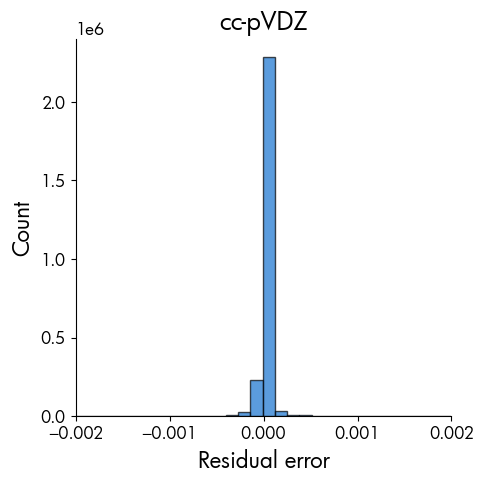

In [20]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(error_2, bins=1000, edgecolor='black', alpha=0.7, color='#1573CF')

ax.set_xlabel('Residual error', fontsize=16)
ax.set_ylabel('Count', fontsize=16)

#ax.yaxis.set_major_formatter(FuncFormatter(formatter))
plt.gca().spines['top'].set_color('none')
plt.gca().spines['right'].set_color('none')

plt.xlim(-0.002,0.002)
plt.title("cc-pVDZ", fontsize=18)
plt.tight_layout()
plt.show()

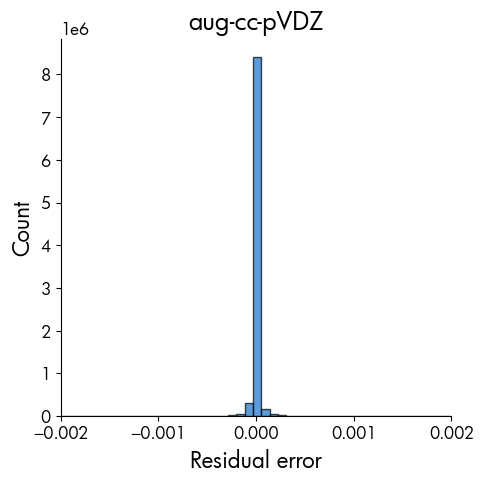

In [21]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(error_3, bins=1000, edgecolor='black', alpha=0.7, color='#1573CF')

ax.set_xlabel('Residual error', fontsize=16)
ax.set_ylabel('Count', fontsize=16)

#ax.yaxis.set_major_formatter(FuncFormatter(formatter))
plt.gca().spines['top'].set_color('none')
plt.gca().spines['right'].set_color('none')

plt.xlim(-0.002,0.002)
plt.title("aug-cc-pVDZ", fontsize=18)
plt.tight_layout()
plt.show()

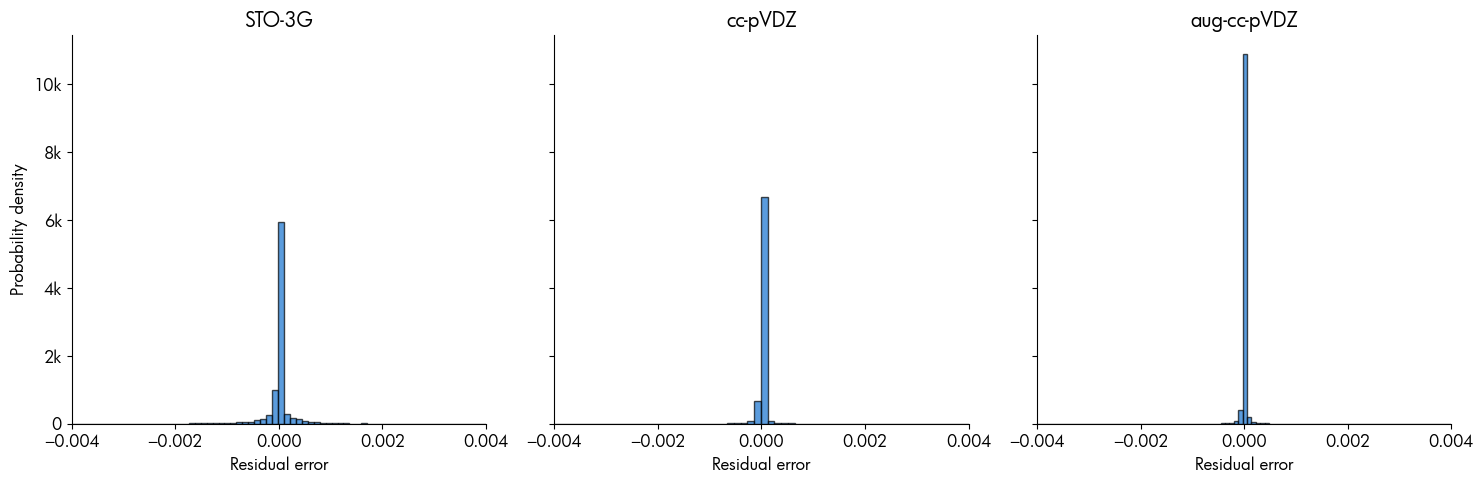

In [23]:
errors = [error, error_2, error_3]
titles = ["STO-3G", "cc-pVDZ", "aug-cc-pVDZ"]
bins_sizes = [400, 1000, 1000]
# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
xticks = [-0.004, -0.002, 0.0, 0.002, 0.004]
for i, (err, title) in enumerate(zip(errors, titles)):
    #axs[i].hist(err, bins=1000, edgecolor='black', alpha=0.7, color='#1573CF')
    axs[i].hist(err, bins=bins_sizes[i], edgecolor='black', alpha=0.7, color='#1573CF', density=True)
    axs[0].set_ylabel('Probability density')
    axs[i].set_xlabel('Residual error')
    axs[i].set_xlim(-0.002, 0.002)
    axs[i].set_xticks(xticks)
    axs[i].set_title(title)
    axs[i].spines['top'].set_color('none')
    axs[i].spines['right'].set_color('none')
    #axs[i].set_yscale('log')
    axs[i].yaxis.set_major_formatter(FuncFormatter(formatter))

axs[0].set_ylabel('Probability density')


plt.tight_layout()
plt.show()

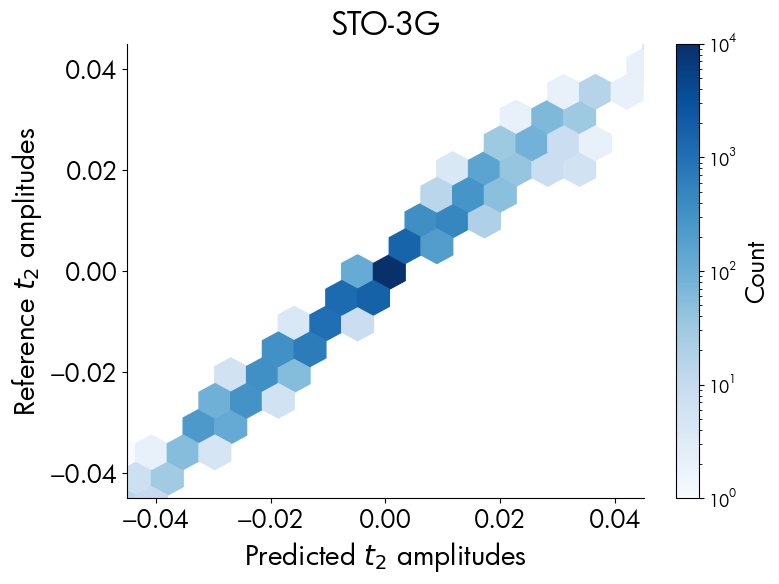

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

hb = ax.hexbin(y_pred, y_test, gridsize=50, cmap='Blues', norm=LogNorm(vmin=1, vmax=10_000))

ax.set_xlabel('Predicted $t_2$ amplitudes', fontsize=20)
ax.set_ylabel('Reference $t_2$ amplitudes', fontsize=20)

ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')

xticks = [-0.04, -0.02, 0.00, 0.02, 0.04]
ax.set_xticks(xticks)
ax.set_yticks(xticks)
ax.tick_params(axis='both', labelsize=18)

ax.set_xlim(-0.045, 0.045)
ax.set_ylim(-0.045, 0.045)

cbar = fig.colorbar(hb, ax=ax)
cbar.set_label('Count', fontsize=18)
ax.set_title("STO-3G", fontsize=23)

plt.tight_layout()
plt.savefig("ref_pred.svg", format='svg', dpi=300)
plt.show()

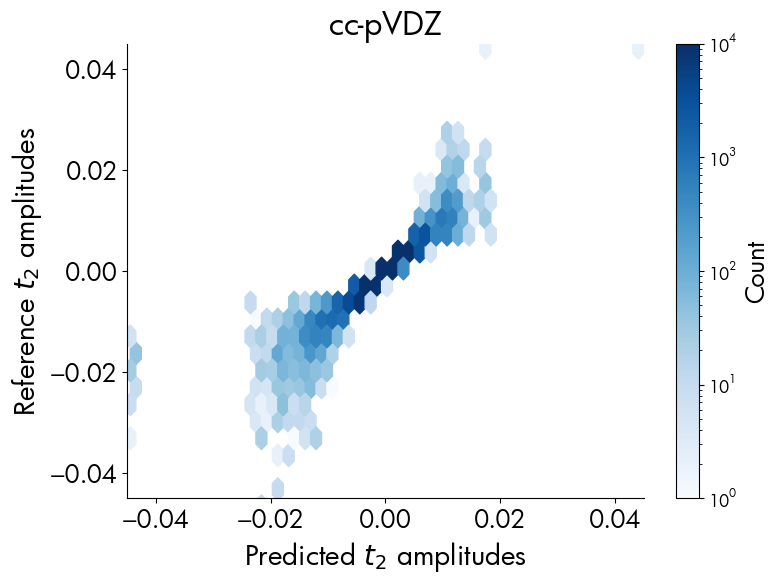

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))

hb = ax.hexbin(y_pred_2, y_test_2, gridsize=50, cmap='Blues', norm=LogNorm(vmin=1, vmax=10_000))

ax.set_xlabel('Predicted $t_2$ amplitudes', fontsize=20)
ax.set_ylabel('Reference $t_2$ amplitudes', fontsize=20)

ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')

xticks = [-0.04, -0.02, 0.00, 0.02, 0.04]
ax.set_xticks(xticks)
ax.set_yticks(xticks)
ax.tick_params(axis='both', labelsize=18)

ax.set_xlim(-0.045, 0.045)
ax.set_ylim(-0.045, 0.045)

cbar = fig.colorbar(hb, ax=ax)
cbar.set_label('Count', fontsize=18)
ax.set_title("cc-pVDZ", fontsize=23)

plt.tight_layout()
plt.savefig("ref_pred.svg", format='svg', dpi=300)
plt.show()

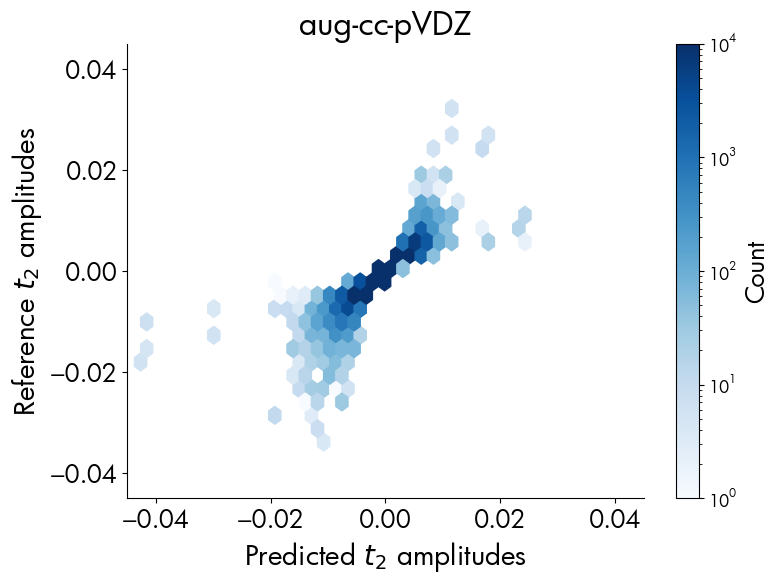

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))

hb = ax.hexbin(y_pred_3, y_test_3, gridsize=50, cmap='Blues', norm=LogNorm(vmin=1, vmax=10_000))

ax.set_xlabel('Predicted $t_2$ amplitudes', fontsize=20)
ax.set_ylabel('Reference $t_2$ amplitudes', fontsize=20)

ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')

xticks = [-0.04, -0.02, 0.00, 0.02, 0.04]
ax.set_xticks(xticks)
ax.set_yticks(xticks)
ax.tick_params(axis='both', labelsize=18)

ax.set_xlim(-0.045, 0.045)
ax.set_ylim(-0.045, 0.045)

cbar = fig.colorbar(hb, ax=ax)
cbar.set_label('Count', fontsize=18)
ax.set_title("aug-cc-pVDZ", fontsize=23)

plt.tight_layout()
plt.savefig("ref_pred.svg", format='svg', dpi=300)
plt.show()

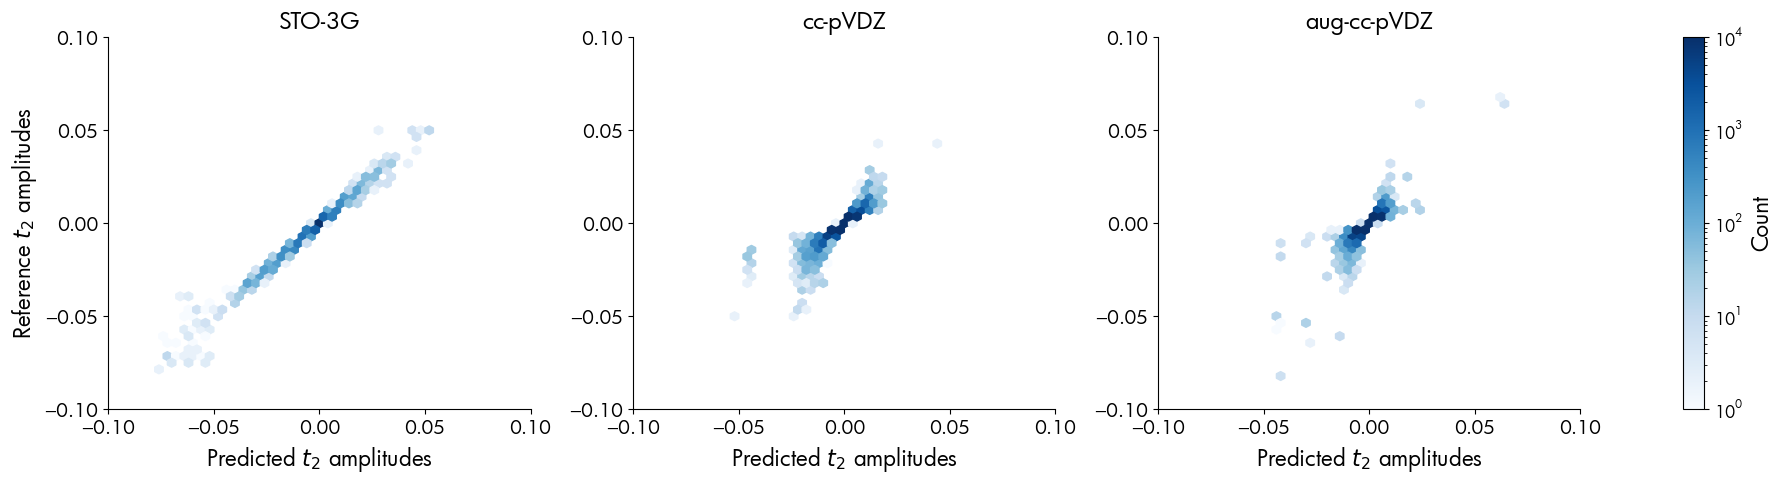

In [27]:
fig = plt.figure(figsize=(18, 5))
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05]) 

predictions = [y_pred, y_pred_2, y_pred_3]
tests_subsets = [y_test, y_test_2, y_test_3]
titles = ["STO-3G", "cc-pVDZ", "aug-cc-pVDZ"]

axs = [plt.subplot(gs[i]) for i in range(3)]

for i, (y_p, title) in enumerate(zip(predictions, titles)):
    hb = axs[i].hexbin(
        y_p, tests_subsets[i],
        gridsize=50,
        cmap='Blues',
        norm=LogNorm(vmin=1, vmax=10_000),
        extent=(-0.1, 0.1, -0.1, 0.1)
    )
    axs[i].set_title(title, fontsize=17)
    axs[i].set_xlim(-0.1, 0.1)
    axs[i].set_ylim(-0.1, 0.1)

    xticks = [-0.1, -0.05, 0.00, 0.05, 0.1]
    axs[i].set_xticks(xticks)
    axs[i].set_yticks(xticks)
    axs[i].tick_params(axis='both', labelsize=14)


    axs[i].set_xlabel('Predicted $t_2$ amplitudes', fontsize=16)
    axs[i].spines['top'].set_color('none')
    axs[i].spines['right'].set_color('none')

axs[0].set_ylabel('Reference $t_2$ amplitudes', fontsize=16)

cax = plt.subplot(gs[3])
cbar = fig.colorbar(hb, cax=cax)
cbar.set_label('Count', fontsize=16)

plt.tight_layout()
plt.savefig("combined_pred.svg", format='svg', dpi=300)
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


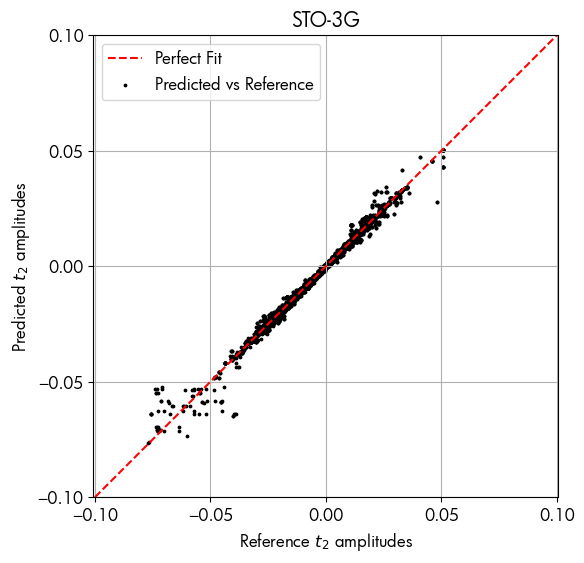

In [29]:
plt.figure(figsize=(6, 6))

plt.plot([-0.1, 0.1], [-0.1, 0.1], color='red', linestyle='--', label='Perfect Fit')

plt.scatter(y_test, y_pred, color='black', label='Predicted vs Reference', s=3)

plt.axis('equal')
plt.xlim(-0.1, 0.1)
plt.ylim(-0.1, 0.1)
plt.xticks(np.arange(-0.1, 0.11, 0.05))
plt.yticks(np.arange(-0.1, 0.11, 0.05))

plt.title("STO-3G")
plt.xlabel('Reference $t_2$ amplitudes')
plt.ylabel('Predicted $t_2$ amplitudes')
plt.grid(True)

plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


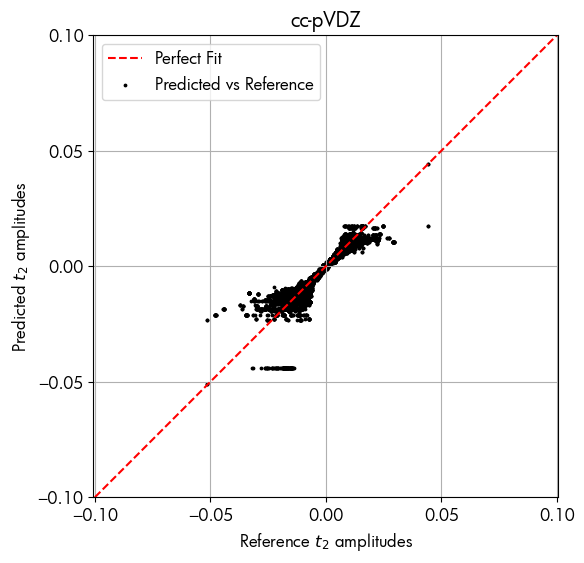

In [30]:
plt.figure(figsize=(6, 6))

plt.plot([-0.1, 0.1], [-0.1, 0.1], color='red', linestyle='--', label='Perfect Fit')

plt.scatter(y_test_2, y_pred_2, color='black', label='Predicted vs Reference', s=3)

plt.axis('equal')
plt.xlim(-0.1, 0.1)
plt.ylim(-0.1, 0.1)
plt.xticks(np.arange(-0.1, 0.11, 0.05))
plt.yticks(np.arange(-0.1, 0.11, 0.05))

plt.title("cc-pVDZ")
plt.xlabel('Reference $t_2$ amplitudes')
plt.ylabel('Predicted $t_2$ amplitudes')
plt.grid(True)

plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


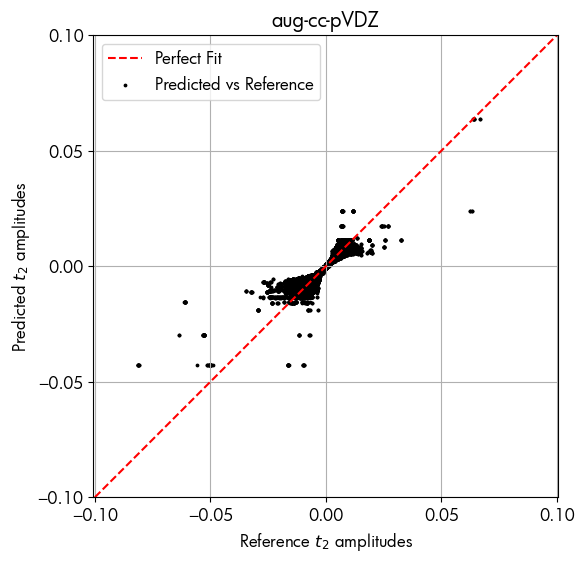

In [31]:
plt.figure(figsize=(6, 6))

plt.plot([-0.1, 0.1], [-0.1, 0.1], color='red', linestyle='--', label='Perfect Fit')

plt.scatter(y_test_3, y_pred_3, color='black', label='Predicted vs Reference', s=3)

plt.axis('equal')
plt.xlim(-0.1, 0.1)
plt.ylim(-0.1, 0.1)
plt.xticks(np.arange(-0.1, 0.11, 0.05))
plt.yticks(np.arange(-0.1, 0.11, 0.05))

plt.title("aug-cc-pVDZ")
plt.xlabel('Reference $t_2$ amplitudes')
plt.ylabel('Predicted $t_2$ amplitudes')
plt.grid(True)

plt.show()

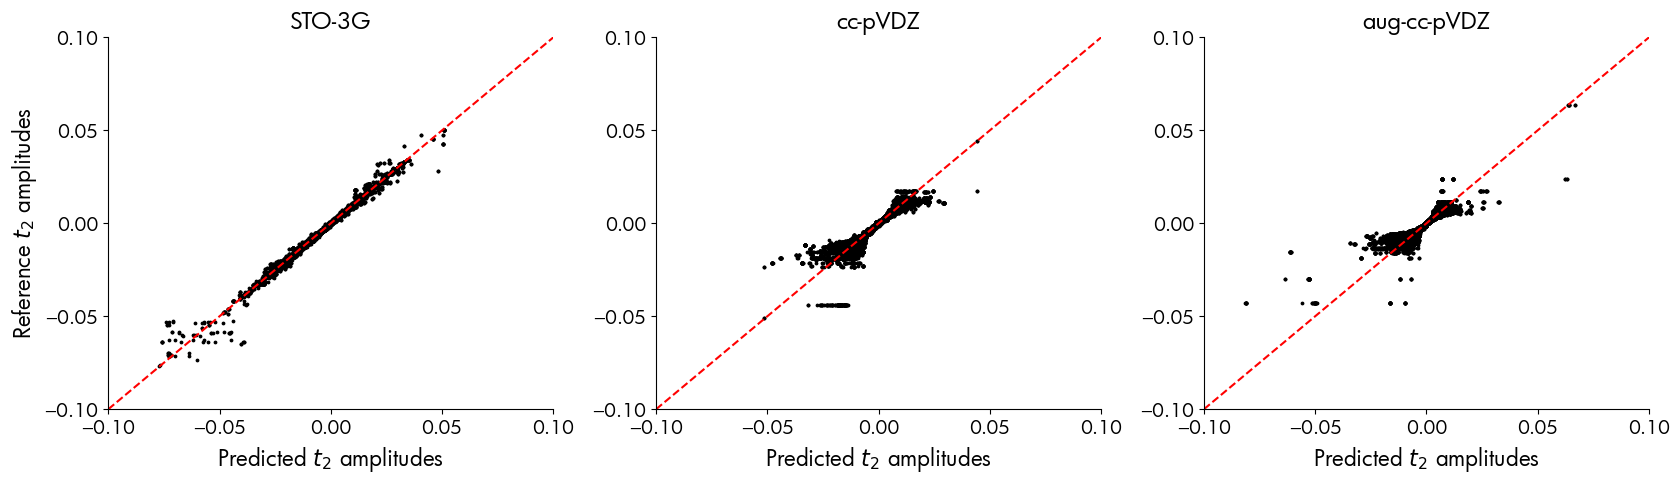

In [34]:
fig = plt.figure(figsize=(18, 5))
#gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05]) 

predictions = [y_pred, y_pred_2, y_pred_3]
tests_subsets = [y_test, y_test_2, y_test_3]
titles = ["STO-3G", "cc-pVDZ", "aug-cc-pVDZ"]

axs = [plt.subplot(gs[i]) for i in range(3)]

for i, (y_p, title) in enumerate(zip(predictions, titles)):
    axs[i].plot([-0.1, 0.1], [-0.1, 0.1], color='red', linestyle='--', label='Perfect Fit')
    axs[i].scatter(tests_subsets[i], y_p, color='black', label='Predicted vs Reference', s=3)
    
    axs[i].set_title(title, fontsize=17)
    axs[i].set_xlim(-0.1, 0.1)
    axs[i].set_ylim(-0.1, 0.1)

    xticks = [-0.1, -0.05, 0.00, 0.05, 0.1]
    axs[i].set_xticks(xticks)
    axs[i].set_yticks(xticks)
    axs[i].tick_params(axis='both', labelsize=14)


    axs[i].set_xlabel('Predicted $t_2$ amplitudes', fontsize=16)
    axs[i].spines['top'].set_color('none')
    axs[i].spines['right'].set_color('none')

axs[0].set_ylabel('Reference $t_2$ amplitudes', fontsize=16)

#cax = plt.subplot(gs[3])
#cbar = fig.colorbar(hb, cax=cax)
#cbar.set_label('Count', fontsize=16)

plt.tight_layout()
#plt.savefig("combined_pred.svg", format='svg', dpi=300)
plt.show()

## STO-3G performance
N: 10, MAE: 0.0003061269979620203, RMSE: 0.0037640880640455827, R2: 0.7676764878231661 <br>
N: 20, MAE: 0.0001429775419770101, RMSE: 0.0006323885667943092, R2: 0.9934424496700677 <br>
N: 40, MAE: 0.00011416410932380572, RMSE: 0.0005225211895203638, R2: 0.9955230584213859 <br>
N: 60, MAE: 0.00010775413538942215, RMSE: 0.0005084098074196536, R2: 0.9957616047642376 <br>
N: 80, MAE: 0.00010253405042620865, RMSE: 0.0005019661664701043, R2: 0.995868359698306 <br>
N: 100, MAE: 9.970629861774098e-05, RMSE: 0.0005165228029624035, R2: 0.9956252563277743 <br>

## cc-pVDZ performance
N: 10, MAE: 3.402683789446091e-05, RMSE: 0.0003901514662986885, R2: 0.9003862299546302 <br>
N: 20, MAE: 3.2123023381844337e-05, RMSE: 0.00038354509787292835, R2: 0.9037311546755417 <br>
N: 40, MAE: 3.12251442698022e-05, RMSE: 0.00038237019846431, R2: 0.9043200448636717 <br>
N: 60, MAE: 3.042337738702325e-05, RMSE: 0.0003758427821800151, R2: 0.9075588544494972 <br>
N: 80, MAE: 3.0591378528603053e-05, RMSE: 0.00037828073988276025, R2: 0.906355699550255 <br>
N: 100, MAE: 3.0265083450369752e-05, RMSE: 0.00037849364254374877, R2: 0.9062502607630246 <br>

## aug-cc-pVDZ performance
N: 10, MAE: 1.913434451136634e-05, RMSE: 0.00018596208617857802, R2: 0.9250580307897667 <br>
N: 20, MAE: 1.8468496450280462e-05, RMSE: 0.00018422700135631824, R2: 0.9264499710763333 <br>
N: 40, MAE: 1.80019375133377e-05, RMSE: 0.00018315347662328587, R2: 0.9273046527877226 <br>
N: 60, MAE: 1.7812372197703567e-05, RMSE: 0.00018064810472378655, R2: 0.9292798618341043 <br>
N: 80, MAE: 1.7949678302887403e-05, RMSE: 0.0001819042758903047, R2: 0.9282929102164369 <br>
N: 100, MAE: 1.7797565529948354e-05, RMSE: 0.00018030884122130993, R2: 0.9295452422230965 <br>

In [35]:
samples = [10, 20, 40, 60, 80, 100]

theory = ['STO-3G', 'cc-pVDZ', 'aug-cc-pVDZ']

mae_results = {
    'STO-3G': [
        0.0003061269979620203,
        0.0001429775419770101,
        0.00011416410932380572,
        0.00010775413538942215,
        0.00010253405042620865,
        9.970629861774098e-05
    ],
    'cc-pVDZ': [
        3.402683789446091e-05,
        3.2123023381844337e-05,
        3.12251442698022e-05,
        3.042337738702325e-05,
        3.0591378528603053e-05,
        3.0265083450369752e-05
    ],
    'aug-cc-pVDZ': [
        1.913434451136634e-05,
        1.8468496450280462e-05,
        1.80019375133377e-05,
        1.7812372197703567e-05,
        1.7949678302887403e-05,
        1.7797565529948354e-05
    ]
}

rmse_results = {
    'STO-3G': [
        0.0037640880640455827,
        0.0006323885667943092,
        0.0005225211895203638,
        0.0005084098074196536,
        0.0005019661664701043,
        0.0005165228029624035
    ],
    'cc-pVDZ': [
        0.0003901514662986885,
        0.00038354509787292835,
        0.00038237019846431,
        0.0003758427821800151,
        0.00037828073988276025,
        0.00037849364254374877
    ],
    'aug-cc-pVDZ': [
        0.00018596208617857802,
        0.00018422700135631824,
        0.00018315347662328587,
        0.00018064810472378655,
        0.0001819042758903047,
        0.00018030884122130993
    ]
}

r2_results = {
    'STO-3G': [
        0.7676764878231661,
        0.9934424496700677,
        0.9955230584213859,
        0.9957616047642376,
        0.995868359698306,
        0.9956252563277743
    ],
    'cc-pVDZ': [
        0.9003862299546302,
        0.9037311546755417,
        0.9043200448636717,
        0.9075588544494972,
        0.906355699550255,
        0.9062502607630246
    ],
    'aug-cc-pVDZ': [
        0.9250580307897667,
        0.9264499710763333,
        0.9273046527877226,
        0.9292798618341043,
        0.9282929102164369,
        0.9295452422230965
    ]
}

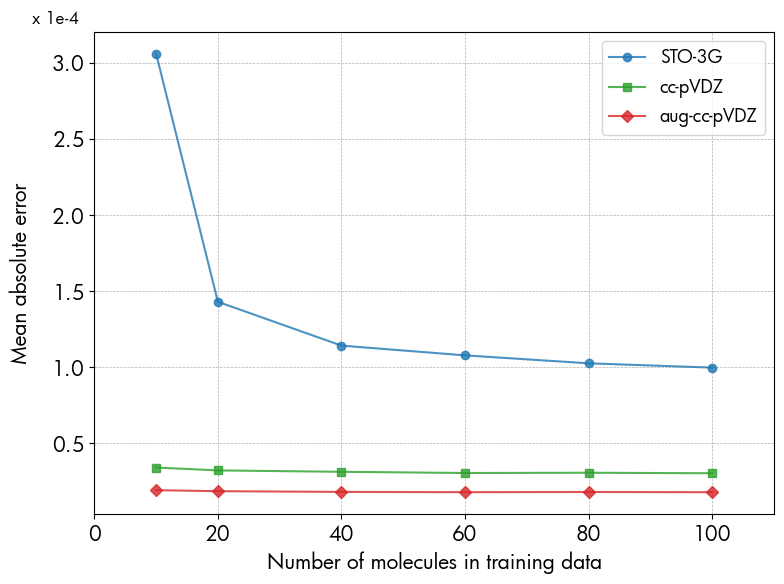

In [39]:
styles = {
    "STO-3G": {"color": "tab:blue", "marker": "o"},
    "cc-pVDZ": {"color": "tab:green", "marker": "s"},
    "aug-cc-pVDZ": {"color": "tab:red", "marker": "D"}
}

fig, ax = plt.subplots(figsize=(8, 6))

for model, mae in mae_results.items():
    scaled_mae = [m * 1e4 for m in mae]
    ax.plot(
        samples,
        scaled_mae,
        marker=styles[model]["marker"],
        color=styles[model]["color"],
        linestyle="-",
        label=model,
        markersize=6,
        linewidth=1.5,
        alpha=0.8
    )

ax.set_xlabel("Number of molecules in training data", fontsize=15)
ax.set_ylabel("Mean absolute error", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-4, -4))
ax.yaxis.set_major_formatter(formatter)

ax.ticklabel_format(style='plain', axis='y')
ax.tick_params(axis='both', which='major', labelsize=15)

ax.annotate("x 1e-4", xy=(0, 1), xycoords=('axes fraction', 'axes fraction'),
            xytext=(-45, 3), textcoords='offset points',
            ha='left', va='bottom', fontsize=12)

ax.legend(fontsize=13)
plt.tight_layout()
plt.xlim(0, 110)
plt.show()


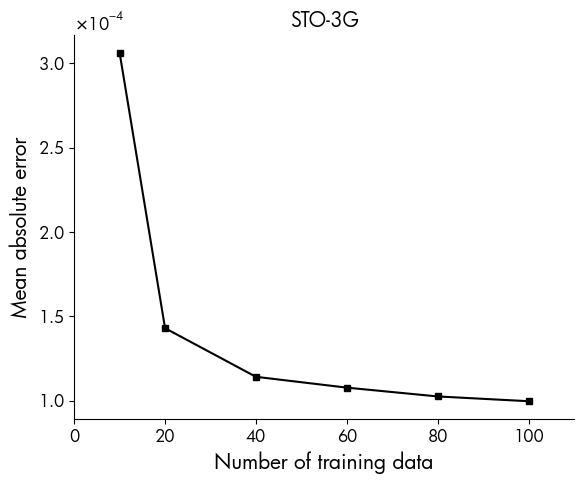

In [41]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(samples, mae_results['STO-3G'], 's-', label='MAE', color='black', markersize=5)

ax.set_xlabel("Number of training data", fontsize=15)
ax.set_ylabel("Mean absolute error", fontsize=15)

ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')

#ax.set_yscale("log")

# Use scalar formatter with scientific notation
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-4, -4))  # Force 10^-4 scaling
ax.yaxis.set_major_formatter(formatter)

plt.xlim(0, 110)
plt.title("STO-3G")
plt.tight_layout()
plt.show()


# Average over molecules

In [1]:
import psutil
import sys
# !{sys.executable} --version
# !{sys.executable} -m pip install shap --upgrade 
import joblib
import time
from shutil import copy
import numpy as np
import pandas as pd
#import tensorflow as tf
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from sklearn.metrics import mean_absolute_error, r2_score

from glob import glob
import psi4
from helper_CC_ML_spacial import HelperCCEnergy
# from helper_CC_ML import *

from glob import glob
import random

  Threads set to 12 by Python driver.


In [2]:
properties=['Evir1', 'Hvir1', 'Jvir1', 'Kvir1', 'Evir2', 'Hvir2', 'Jvir2', 'Kvir2', 'Eocc1', 'Jocc1', 'Kocc1', 'Hocc1','Eocc2', 'Jocc2', 'Kocc2', 'Hocc2', 'Jia1', 'Jia2', 'Kia1', 'Kia2','diag', 'orbdiff', 'doublecheck', 't2start', 't2mag', 't2sign', 'Jia1mag', 'Jia2mag','Kia1mag', 'Kia2mag']

In [3]:
with open('out_of_data.txt','r') as f:
    lines = f.readlines()
    
filenames = [element[:-1] for element in lines]
filenames[:4]

['../machine_learning/data/methane72.xyz',
 '../machine_learning/data/ammonia159.xyz',
 '../machine_learning/data/methane5.xyz',
 '../machine_learning/data/water91.xyz']

In [51]:
basis_sets = ['STO-3G','cc-pVDZ','aug-cc-pVDZ']
best5=["doublecheck","t2start","t2mag","orbdiff","diag"]

n_list = [20, 40, 60, 80, 100] # iterating over N=20,40,60,80,100 training molecules
n_list = [20]
mean_deviations = []
mean_iter_to_converge = []

for basis in basis_sets:
    for n in n_list:
        print(f"Processing N={n} molecules with {basis} basis set")

        data_path = f"/mnt/c/Users/Maxim/Documents/Toronto/Research/code/out/faster_{basis}_data_splits_{n}.pkl"
        print(data_path)
        print("Training model..")

        with open(data_path,'rb') as f:
            data = joblib.load(f)            # import model

        X_train = data["X_train"]
        y_train = data["y_train"]
        X_test = data["X_test"]
        y_test = data["y_test"]
        
         
        model = xgb.XGBRegressor(
            n_estimators=400,
            max_depth=12,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            reg_alpha=0.0,
            tree_method="hist",
            n_jobs=-1,
            random_state=42
        )
        
        model_pipeline = Pipeline([
            ('scaler', MinMaxScaler(feature_range=(-1,1))),
            ('regressor', model)
        ])

        t1 = time.time()
        model_pipeline.fit(X_train, y_train)
        t2 = time.time()
        
        y_pred = model_pipeline.predict(X_test)
        
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        
        print(f"N: {n}, MAE: {mae}, MSE: {mse}, R2: {r2}")
        print(f"Finished training in {t2-t1} seconds \n")
        
        ml_iter_list = []
        ml_dev = []
        ml_time_to_converge_list = []
        for fn in filenames[:50]:
            print(f"Processing {fn}")       # import xyz file
            with open(fn,'r') as f:
                text=f.read()
            mol = psi4.geometry(text)                
            
            psi4.core.clean()
            psi4.core.be_quiet()
            
            psi4.set_options({'basis': basis,
                              'scf_type':     'pk',
                              'reference':    'rohf',
                              'mp2_type':     'conv',
                              'e_convergence': 1e-8,
                              'd_convergence': 1e-8})

            rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)        # rhf_e is Hartree-Fock energy 
            scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
            
            A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=True)
            # Here is the "normal" way to initialize i.e. NOT Machine Learning predicted, NOT random, NOT all zeros
            MP2T2=A.t2start
            A.t1 = np.zeros((A.t1.shape))
            A.t2 = MP2T2

            # GMJ go back and fix these lists to save this data
            MP2E = A.compute_energy(iterate=False)# MP2 (initial) energy
            CCSDE = A.compute_energy()# exact CCSD energy
        
            normal_dev.append(abs(MP2E-CCSDE))  # energy deviation from CCSD
            
            # Here we are initializing with the ML predicted t2-amplitudes, first we predict using the top 5 features
            y_pred = model.predict(np.vstack([getattr(A,i).flatten() for i in best5]).T)
            
            A.t1 = np.zeros((A.t1.shape))
            A.t2 = y_pred.reshape(*A.t2.shape)
            A.t2start = y_pred.reshape(*A.t2.shape)

            # mlE_0 = A.compute_energy(iterate=False)   # GMJ this is MP2 energy
            mlE = A.compute_energy()                # GMJ exact CCSD energy calculated using injected DDCC parameters 
                    
            ml_dev.append(abs(MP2E-mlE))  # energy deviation from MP2
            ml_dev.append(abs(CCSDE-mlE))  # energy deviation from CCSD
            
            mlHistory = A.history               # tuple, (iteration_nunber, CCSDcorr_E)
            mlHistory.insert(0, (0,mlE_0))     # inserting the INITIAL t2 amplitude from ML method
            
            #for i in mlHistory:
            #    print(i)
            #print("\n")
            
            iterations = len(mlHistory)     # number of iterations to converge
            #print(f"No. of iterations to converge: {iterations}")
            ml_iter_list.append(iterations)
            
            ml_time_to_converge = A.time_to_converge 
            ml_time_to_converge_list.append(ml_time_to_converge)
            #print(f"Time to converge: {ml_time_to_converge}")
            
            features = pd.DataFrame(np.array([getattr(A,attr).flatten() for attr in properties]).T,columns=properties)
            #print(f"Features: \n{features}")

        print("\n")
        print("Iterations for each molecule list: ", ml_iter_list)
        print("Mean iterations to converge: ", np.mean(ml_iter_list))
        print("Deviations from CCSD for each molecule: ", ml_dev)
        print(f"Mean deviation from CCSD: {np.mean(ml_dev)} (Eₕ)")
        print("Times to converge for each molecule: ", ml_time_to_converge_list)
        print("Mean time to converge", np.mean(ml_time_to_converge_list), " seconds")

        mean_deviations.append((basis, n, np.mean(ml_dev)))
        mean_iter_to_converge.append((basis, n, np.mean(ml_iter_list)))
        print("aa: here: ", mean_deviations)
        print("Next model...\n")


Processing N=20 molecules with STO-3G basis set
/mnt/c/Users/Maxim/Documents/Toronto/Research/code/out/faster_STO-3G_data_splits_20.pkl
Training model..
N: 20, MAE: 0.00022612851535391197, MSE: 7.514063191818838e-07, R2: 0.9861144058567034
Finished training in -48.05548667907715 seconds 

Processing ../machine_learning/data/methane72.xyz
Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 9 basis functions.
(9, 9)
(8, 8)
Building initial guess...

..initialized CCSD in 0.116 seconds.

CCSD Iteration   0: CCSD correlation = -0.045420775701298   dE =  4.54208E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.045420775701298   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.045420775701298   dE =  4.54208E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.069391584627120   dE = -2.39708E-02   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.075838024924073   dE = -6.44644E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.078654783631846   dE = -2.81676E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.078965937040208   dE = -3.11153E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.079039342506054   dE = -7.34055E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 8 basis functions.
(8, 8)
(7, 7)
Building initial guess...

..initialized CCSD in 0.081 seconds.

CCSD Iteration   0: CCSD correlation = -0.037595770053634   dE =  3.75958E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.037595770053634   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.037595770053634   dE =  3.75958E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.058239943013197   dE = -2.06442E-02   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.063028437158248   dE = -4.78849E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.064855986930710   dE = -1.82755E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.064925473277907   dE = -6.94863E-05   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.064949605127467   dE = -2.41318E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation

...

Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 50 basis functions.
(50, 50)
(49, 49)
Building initial guess...

..initialized CCSD in 0.992 seconds.

CCSD Iteration   0: CCSD correlation = -0.021223637008897   dE =  2.12236E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.021223637008897   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.005 seconds!
CCSD Iteration   0: CCSD correlation = -0.021223637008897   dE =  2.12236E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.202992564991223   dE = -1.81769E-01   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.209740352479584   dE = -6.74779E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.213522296907928   dE = -3.78194E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.214088454982730   dE = -5.66158E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.214336468057812   dE = -2.48013E-04   DIIS = 4
CCSD Iteration   6: CCSD correl

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 2 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 64 basis functions.
(64, 64)
(62, 62)
Building initial guess...

..initialized CCSD in 3.303 seconds.

CCSD Iteration   0: CCSD correlation = -0.005904035126121   dE =  5.90404E-03   MP2
CCSD Iteration   1: CCSD correlation = -0.005904035126121   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.005 seconds!
CCSD Iteration   0: CCSD correlation = -0.005904035126121   dE =  5.90404E-03   MP2
CCSD Iteration   1: CCSD correlation = -0.335860059423215   dE = -3.29956E-01   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.335867417941423   dE = -7.35852E-06   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.348236740848186   dE = -1.23693E-02   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.348168895531599   dE =  6.78453E-05   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.349337376496560   dE = -1.16848E-03   DIIS = 4
CCSD Iteration   6: CCSD correl

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 2 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 82 basis functions.
(82, 82)
(80, 80)
Building initial guess...

..initialized CCSD in 9.271 seconds.

CCSD Iteration   0: CCSD correlation = -0.053250807935391   dE =  5.32508E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.053250807935391   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.013 seconds!
CCSD Iteration   0: CCSD correlation = -0.053250807935391   dE =  5.32508E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.368889742947464   dE = -3.15639E-01   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.374080167168211   dE = -5.19042E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.381568417980078   dE = -7.48825E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.381860061060691   dE = -2.91643E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.382390506993124   dE = -5.30446E-04   DIIS = 4
CCSD Iteration   6: CCSD correl

In [52]:
mean_deviations

[('STO-3G', 20, np.float64(0.05968167199842092)),
 ('cc-pVDZ', 20, np.float64(0.24125775414230108)),
 ('aug-cc-pVDZ', 20, np.float64(0.25382922349090453))]

In [53]:
mean_iter_to_converge

[('STO-3G', 20, np.float64(12.04)),
 ('cc-pVDZ', 20, np.float64(13.42)),
 ('aug-cc-pVDZ', 20, np.float64(14.52))]

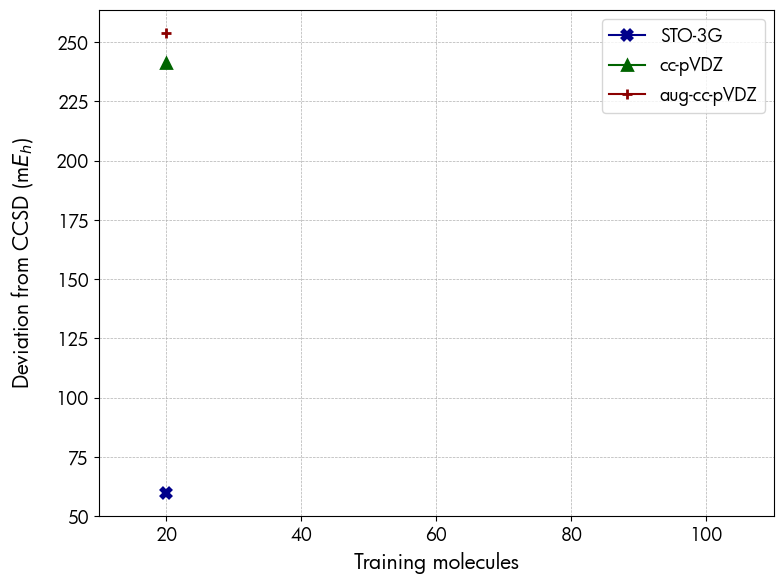

In [54]:
grouped = defaultdict(lambda: ([], []))  # {basis: ([n], [dev])}

for basis, n, dev in mean_deviations:
    grouped[basis][0].append(n)
    grouped[basis][1].append(dev * 1000)  # Convert E_h to mE_h

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

marker_styles = {
    'STO-3G': 'x',      # cross
    'cc-pVDZ': '^',     # triangle
    'aug-cc-pVDZ': '+'  # plus
}

color_styles = {
    'STO-3G': 'darkblue',
    'cc-pVDZ': 'darkgreen',
    'aug-cc-pVDZ': 'darkred'
}

for basis, (n_list, dev_list) in grouped.items():
    marker = marker_styles.get(basis, 'x')
    color = color_styles.get(basis, 'black')

    if marker == 'x':
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=4, color=color)  # Thicker cross
    else:
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=2, color=color)

ax.set_xlabel("Training molecules", fontsize=15)
ax.set_ylabel("Deviation from CCSD (m$E_h$)", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=13)

plt.tight_layout()
plt.xlim(10, 110)
plt.show()

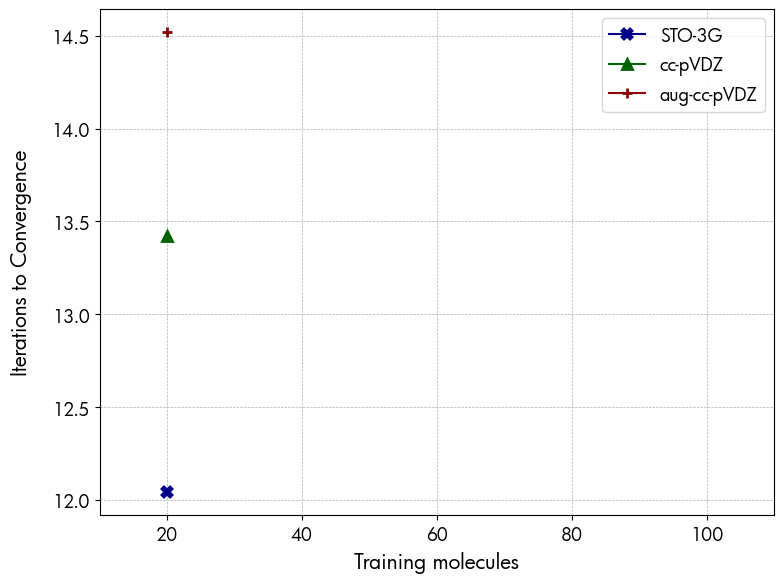

In [55]:
grouped = defaultdict(lambda: ([], []))  # {basis: ([n], [dev])}

for basis, n, it in mean_iter_to_converge:
    grouped[basis][0].append(n)
    grouped[basis][1].append(it)  # Convert E_h to mE_h

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

marker_styles = {
    'STO-3G': 'x',      # cross
    'cc-pVDZ': '^',     # triangle
    'aug-cc-pVDZ': '+'  # plus
}

color_styles = {
    'STO-3G': 'darkblue',
    'cc-pVDZ': 'darkgreen',
    'aug-cc-pVDZ': 'darkred'
}

for basis, (n_list, dev_list) in grouped.items():
    marker = marker_styles.get(basis, 'x')
    color = color_styles.get(basis, 'black')

    if marker == 'x':
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=4, color=color)  # Thicker cross
    else:
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=2, color=color)

ax.set_xlabel("Training molecules", fontsize=15)
ax.set_ylabel("Iterations to Convergence", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=13)

plt.tight_layout()
plt.xlim(10, 110)
plt.show()

In [ ]:
################

In [4]:
fn = "out/test_names.txt"
with open(fn, 'r') as f:
    filenames = [line.strip() for line in f]

print(filenames)

['data/ethane140.xyz', 'data/ethylene53.xyz', 'data/methane173.xyz', 'data/formaldehyde18.xyz', 'data/methane104.xyz', 'data/methane17.xyz', 'data/ammonia144.xyz', 'data/water120.xyz', 'data/water35.xyz', 'data/methanol30.xyz', 'data/methanol45.xyz', 'data/ethylene100.xyz', 'data/ammonia19.xyz', 'data/ammonia123.xyz', 'data/methane60.xyz', 'data/ethane108.xyz', 'data/ammonia120.xyz', 'data/formaldehyde120.xyz', 'data/methane134.xyz', 'data/ammonia166.xyz', 'data/ethylene98.xyz', 'data/methane94.xyz', 'data/ammonia133.xyz', 'data/ethane55.xyz', 'data/ammonia192.xyz', 'data/methane145.xyz', 'data/formaldehyde91.xyz', 'data/ammonia141.xyz', 'data/ammonia104.xyz', 'data/formaldehyde118.xyz', 'data/ethane163.xyz', 'data/ammonia147.xyz', 'data/formaldehyde66.xyz', 'data/formaldehyde163.xyz', 'data/formaldehyde180.xyz', 'data/ethane57.xyz', 'data/methane109.xyz', 'data/water71.xyz', 'data/water170.xyz', 'data/ethylene55.xyz', 'data/methane181.xyz', 'data/formaldehyde173.xyz', 'data/formaldehy

In [6]:
basis_sets = ['aug-cc-pVDZ']
best5=["doublecheck","t2start","t2mag","orbdiff","diag"]

n_list = [10, 20, 40, 60, 80, 100] # iterating over N=10, 20, 40, 60, 80, 100 training molecules
n_list = [100]

mean_deviations = []
mean_iter_to_converge = []

for basis in basis_sets:
    for n in n_list:
        print(f"Processing N={n} molecules with {basis} basis set")
        
        fn = f"out/optimised_{basis}_best_model_{n}.pkl"
        model = joblib.load(fn)
        
        ml_iter_list = []
        ml_dev = []
        ml_time_to_converge_list = []
        for fn in filenames:
            print(f"Processing {fn}")       # import xyz file
            with open(fn,'r') as f:
                text=f.read()
            mol = psi4.geometry(text)                
            
            psi4.core.clean()
            psi4.core.be_quiet()
            
            psi4.set_options({'basis': basis,
                              'scf_type':     'pk',
                              'reference':    'rohf',
                              'mp2_type':     'conv',
                              'e_convergence': 1e-8,
                              'd_convergence': 1e-8})

            rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)        # rhf_e is Hartree-Fock energy 
            scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
            
            A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=True)

            MP2T2=A.t2start
            A.t1 = np.zeros((A.t1.shape))
            A.t2 = MP2T2
            
            MP2E = A.compute_energy(iterate=False)                    # MP2 (initial) energy
            CCSDE = A.compute_energy() 
            

            A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=True)
            
            # Here we are initializing with the ML predicted t2-amplitudes, first we predict using the top 5 features
            y_pred = model.predict(np.vstack([getattr(A,i).flatten() for i in top5]).T)
            
            A.t1 = np.zeros((A.t1.shape))
            A.t2 = y_pred.reshape(*A.t2.shape)
            A.t2start = y_pred.reshape(*A.t2.shape)

            mlE_0 = A.compute_energy(iterate=False)   # ML-predicted energy
            #mlE = A.compute_energy()                # exact CCSD energy

            
            ml_dev.append(abs(mlE_0-CCSDE))  # energy deviation from CCSD


            print("Deviation here: ", abs(mlE_0-CCSDE), "\n")
            
            mlHistory = A.history               # tuple, (iteration_nunber, CCSDcorr_E)
            mlHistory.insert(0, (0,mlE_0))     # inserting the INITIAL t2 amplitude from ML method
            
            #for i in mlHistory:
            #    print(i)
            #print("\n")
            
            iterations = len(mlHistory)     # number of iterations to converge
            #print(f"No. of iterations to converge: {iterations}")
            ml_iter_list.append(iterations)
            
            ml_time_to_converge = A.time_to_converge 
            ml_time_to_converge_list.append(ml_time_to_converge)
            #print(f"Time to converge: {ml_time_to_converge}")
            
            features = pd.DataFrame(np.array([getattr(A,attr).flatten() for attr in top5]).T,columns=top5)
            #print(f"Features: \n{features}")

        print("\n")
        print("Iterations for each molecule list: ", ml_iter_list)
        print("Mean iterations to converge: ", np.mean(ml_iter_list))
        print("Deviations from CCSD for each molecule: ", ml_dev)
        print(f"Mean deviation from CCSD: {np.mean(ml_dev)} (Eₕ)")
        print("Times to converge for each molecule: ", ml_time_to_converge_list)
        print("Mean time to converge", np.mean(ml_time_to_converge_list), " seconds")

        mean_deviations.append((basis, n, np.mean(ml_dev)))
        mean_iter_to_converge.append((basis, n, np.mean(ml_iter_list)))
        print("aa: here: ", mean_deviations)
        print("Next model...\n")


Processing N=100 molecules with aug-cc-pVDZ basis set
Processing data/ethane140.xyz


/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.2 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.2 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 2 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 82 basis functions.
(82, 82)
(80, 80)
Building initial guess...

..initialized CCSD in 6.404 seconds.

CCSD Iteration   0: CCSD correlation = -0.285492491752848   dE =  2.85492E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.285492491752848   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.014 seconds!
CCSD Iteration   0: CCSD correlation = -0.285492491752848   dE =  2.85492E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.303789981474098   dE = -1.82975E-02   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.311325417465720   dE = -7.53544E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.313612949285216   dE = -2.28753E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.314504596758218   dE = -8.91647E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.314611086796750   dE = -1.06490E-04   DIIS = 4
CCSD Iteration   6: CCSD correl

...

Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 59 basis functions.
(59, 59)
(58, 58)
Building initial guess...

..initialized CCSD in 1.504 seconds.

CCSD Iteration   0: CCSD correlation = -0.185389242939271   dE =  1.85389E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.185389242939271   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.004 seconds!
Deviation here:  0.0059619774438175455 

Processing data/methanol72.xyz
Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 2 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 82 basis functions.
(82, 82)
(80, 80)
Building initial guess...

..initialized CCSD in 5.940 seconds.

CCSD Iteration   0: CCSD correlation = -0.359167396234689   dE =  3.59167E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.359167396234689   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.007 seconds!
CCSD Iteration   0: CCSD correlation = -0.359167396234689   dE =  3.59167E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.371605227863300   dE = -1.24378E-02   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.380281040865322   dE = -8.67581E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.381465255272145   dE = -1.18421E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.382482397882140   dE = -1.01714E-03   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.382572874398688   dE = -9.04765E-05   DIIS = 4
CCSD Iteration   6: CCSD correl

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 2 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 82 basis functions.
(82, 82)
(80, 80)
Building initial guess...

..initialized CCSD in 5.888 seconds.

CCSD Iteration   0: CCSD correlation = -0.386591348808120   dE =  3.86591E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.386591348808120   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.010 seconds!
Deviation here:  0.004008747490856723 



Iterations for each molecule list:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Mean iterations to converge:  1.0
Deviations from CCSD for each molecule:  [np.float64(0.010531758465572083), np.float64(0.008939080535858568), np.float64(0.006450752259461429), np.float64(0.009315980498142307), np.float64(0.00905903759923854), np.float64(0.012813304004519438), np.float64(0.0174268561901349), np.float64(0.0383377

In [7]:
mean_deviations

[('aug-cc-pVDZ', 100, np.float64(0.013364317265573815))]

In [8]:
mean_iter_to_converge

[('aug-cc-pVDZ', 100, np.float64(1.0))]

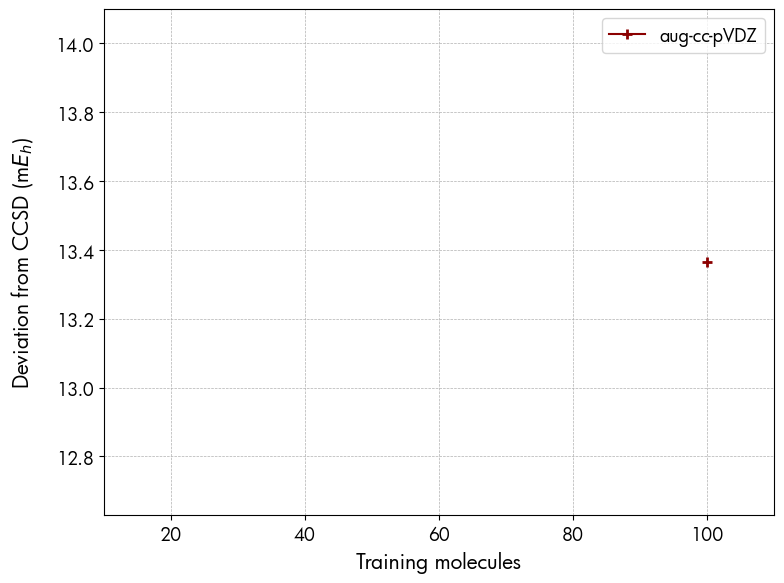

In [9]:
grouped = defaultdict(lambda: ([], []))  # {basis: ([n], [dev])}

for basis, n, dev in mean_deviations:
    grouped[basis][0].append(n)
    grouped[basis][1].append(dev * 1000)  # Convert E_h to mE_h

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

marker_styles = {
    'STO-3G': 'x',      # cross
    'cc-pVDZ': '^',     # triangle
    'aug-cc-pVDZ': '+'  # plus
}

color_styles = {
    'STO-3G': 'darkblue',
    'cc-pVDZ': 'darkgreen',
    'aug-cc-pVDZ': 'darkred'
}

for basis, (n_list, dev_list) in grouped.items():
    marker = marker_styles.get(basis, 'x')
    color = color_styles.get(basis, 'black')

    if marker == 'x':
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=4, color=color)  # Thicker cross
    else:
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=2, color=color)

ax.set_xlabel("Training molecules", fontsize=15)
ax.set_ylabel("Deviation from CCSD (m$E_h$)", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=13)

plt.tight_layout()
plt.xlim(10, 110)
plt.show()

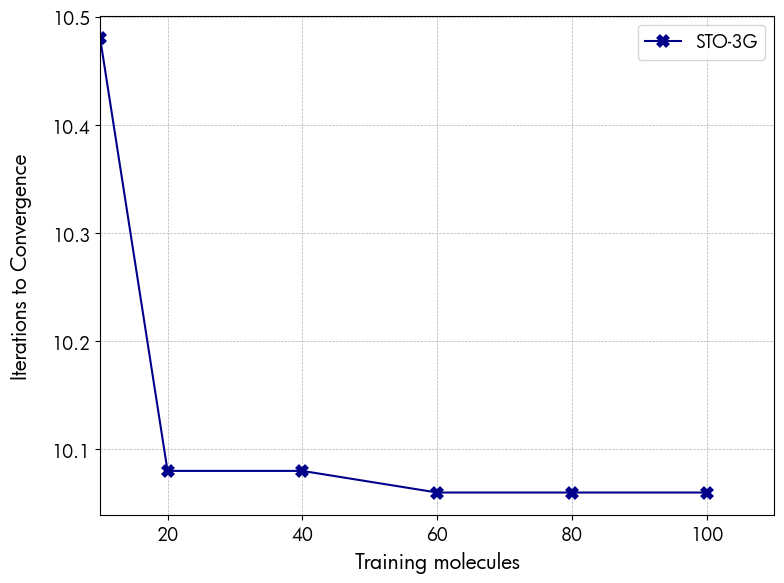

In [74]:
grouped = defaultdict(lambda: ([], []))  # {basis: ([n], [dev])}

for basis, n, it in mean_iter_to_converge:
    grouped[basis][0].append(n)
    grouped[basis][1].append(it)  # Convert E_h to mE_h

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

marker_styles = {
    'STO-3G': 'x',      # cross
    'cc-pVDZ': '^',     # triangle
    'aug-cc-pVDZ': '+'  # plus
}

color_styles = {
    'STO-3G': 'darkblue',
    'cc-pVDZ': 'darkgreen',
    'aug-cc-pVDZ': 'darkred'
}

for basis, (n_list, dev_list) in grouped.items():
    marker = marker_styles.get(basis, 'x')
    color = color_styles.get(basis, 'black')

    if marker == 'x':
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=4, color=color)  # Thicker cross
    else:
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=2, color=color)

ax.set_xlabel("Training molecules", fontsize=15)
ax.set_ylabel("Iterations to Convergence", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=13)

plt.tight_layout()
plt.xlim(10, 110)
plt.show()